In [ ]:
import os
current_working_directory = os.getcwd()
print(f"Current Working Directory (CWD): {current_working_directory}")

In [1]:
# =========================================================
# STEP 1: Load Data and Robustly Import Models (FINAL RELATIVE PATH FIX)
# =========================================================
import sys
from pathlib import Path
from tensorflow.keras.metrics import RootMeanSquaredError
import numpy as np 
import pickle 
import os 

# --- A. Data Loading ---
# The correct relative path to go up one directory (..) and into the Results folder
RESULTS_FOLDER_PATH = os.path.join('..', 'Results') 
print(f"Loading data arrays from relative path: {RESULTS_FOLDER_PATH}...")

# Load the data arrays
try:
    # Use os.path.join to safely construct the paths
    X_train = np.load(os.path.join(RESULTS_FOLDER_PATH, 'X_train.npy'))
    Y_train = np.load(os.path.join(RESULTS_FOLDER_PATH, 'Y_train.npy'))
    X_val = np.load(os.path.join(RESULTS_FOLDER_PATH, 'X_val.npy'))
    Y_val = np.load(os.path.join(RESULTS_FOLDER_PATH, 'Y_val.npy'))
    decoder_input_train = np.load(os.path.join(RESULTS_FOLDER_PATH, 'decoder_input_train.npy'))
    decoder_input_val = np.load(os.path.join(RESULTS_FOLDER_PATH, 'decoder_input_val.npy'))
    X_test = np.load(os.path.join(RESULTS_FOLDER_PATH, 'X_test.npy'))
    Y_test = np.load(os.path.join(RESULTS_FOLDER_PATH, 'Y_test.npy'))
    decoder_input_test = np.load(os.path.join(RESULTS_FOLDER_PATH, 'decoder_input_test.npy'))
    
    # Load the target scaler
    with open(os.path.join(RESULTS_FOLDER_PATH, 'target_scaler.pkl'), 'rb') as file:
        target_scaler = pickle.load(file)
    
    print("All data arrays and scaler successfully loaded.")

except FileNotFoundError:
    print("-" * 50)
    raise FileNotFoundError(
        f"CRITICAL ERROR: Data files not found in the '{RESULTS_FOLDER_PATH}' directory. Please ensure Step 1 was executed successfully."
    )

# --- B. Define Constants (Derived from loaded data) ---
T_IN = X_train.shape[1]
F = X_train.shape[2]
T_OUT = Y_train.shape[1]
N_UNITS = 64 

print(f"Constants derived: T_IN={T_IN}, T_OUT={T_OUT}, F={F}")

# --- C. Import Model Definitions (Path check reused) ---
MODELS_DIR = Path('Models') # This is the folder you are in (CWD)
if str(MODELS_DIR.resolve()) not in sys.path:
    # We don't need this path modification if the notebook is already inside 'Models'
    pass 
try:
    from seq2seq_attention import create_attention_model 
    from baseline_lstm import create_baseline_lstm 
    print("Models imported successfully!")
except ImportError as e:
    raise ImportError(f"Model import failed. Error: {e}")

Loading data arrays from relative path: ..\Results...
All data arrays and scaler successfully loaded.
Constants derived: T_IN=96, T_OUT=24, F=2
Models imported successfully!


In [ ]:
import numpy as np
print("--- NaN Check ---")
print(f"NaNs in X_train: {np.isnan(X_train).sum()}")
print(f"NaNs in Y_train: {np.isnan(Y_train).sum()}")
print(f"NaNs in X_val:   {np.isnan(X_val).sum()}")

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError

# --- CRITICAL FIX: ENABLE EAGER EXECUTION ---
#tf.config.run_functions_eagerly(True) 
#print("Eager execution enabled. Training should now proceed.")
# ---

# --- 1. Instantiate Models (Using uppercase constants) ---
attention_model = create_attention_model(T_IN, T_OUT, F, N_UNITS)
baseline_model = create_baseline_lstm(T_IN, T_OUT, F, N_UNITS)

# --- 2. Define Stabilized Optimizer and Compile Models ---
metrics = ['mae', 'mape', RootMeanSquaredError(name='rmse')]
BATCH_SIZE = 32
EPOCHS = 20 

# --- OPTIMIZER IS NOW DEFINED INSIDE COMPILATION ---

# Compile Attention Model
attention_model.compile(
    # Create a NEW optimizer instance here!
    optimizer=Adam(learning_rate=0.001, clipvalue=1.0), 
    loss='mse', 
    metrics=metrics,
    jit_compile=True
)

# Compile Baseline Model
baseline_model.compile(
    # Create a NEW optimizer instance here!
    optimizer=Adam(learning_rate=0.001, clipvalue=1.0), 
    loss='mse', 
    metrics=metrics,
    jit_compile=True
)

print("--- Model Training Starting ---")
print(f"Epochs: {EPOCHS}, Batch Size: {BATCH_SIZE}")
print("="*40)

# --- 3. Prepare Baseline Target Data ---
Y_train_flat = Y_train.reshape(Y_train.shape[0], -1) 
Y_val_flat = Y_val.reshape(Y_val.shape[0], -1) 

# --- 4. Train the Attention Model ---
print("\n--- Training Seq2Seq Attention Model ---")
attention_history = attention_model.fit(
    [X_train, decoder_input_train], 
    Y_train,
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_data=([X_val, decoder_input_val], Y_val),
    verbose=1
)

# --- 5. Train the Baseline Model ---
print("\n--- Training Baseline LSTM Model ---")
baseline_history = baseline_model.fit(
    X_train, 
    Y_train_flat, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_data=(X_val, Y_val_flat),
    verbose=1
)
print("="*40)
print("Training Complete. Model histories saved.")

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Model Training Starting ---
Epochs: 20, Batch Size: 32

--- Training Seq2Seq Attention Model ---
Epoch 1/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 97s 221ms/step - loss: 0.0072 - mae: 0.0558 - mape: 19277.6172 - rmse: 0.0847 - val_loss: 0.0011 - val_mae: 0.0268 - val_mape: 22.1834 - val_rmse: 0.0337
Epoch 2/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 62s 163ms/step - loss: 0.0033 - mae: 0.0437 - mape: 13540.6738 - rmse: 0.0572 - val_loss: 0.0017 - val_mae: 0.0316 - val_mape: 30.0849 - val_rmse: 0.0408
Epoch 3/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 62s 165ms/step - loss: 0.0031 - mae: 0.0424 - mape: 10834.3857 - rmse: 0.0557 - val_loss: 0.0016 - val_mae: 0.0306 - val_mape: 28.3507 - val_rmse: 0.0399
Epoch 4/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 66s 176ms/step - loss: 0.0031 - mae: 0.0421 - mape: 9478.7617 - rmse: 0.0554 - val_loss: 0.0043 - val_mae: 0.0550 - val_mape: 48.6750 - val_rmse: 0.0656
Epoch 5/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 67s 177ms/step - loss: 0.0031 - mae: 0.0422 - mape: 8973.3848 - rmse: 0.0555 - val_l

In [3]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import os
import pickle

# Define the folder name used for saving/loading
RESULTS_FOLDER = 'Results'

# Load the scaler object (CRITICAL STEP)
try:
    with open(f'{RESULTS_FOLDER}/target_scaler.pkl', 'rb') as f:
        target_scaler = pickle.load(f)
    print("Target scaler loaded successfully.")
except FileNotFoundError:
    print(f"Error: target_scaler.pkl not found in the {RESULTS_FOLDER} directory.")
    # You might need to manually set the target_scaler variable if this fails

# 1. Generate Predictions on the Test Set
print("\n--- Generating Test Predictions ---")
# Attention Model Prediction
att_pred_scaled = attention_model.predict([X_test, decoder_input_test])
# Baseline Model Prediction (requires flattening)
base_pred_flat_scaled = baseline_model.predict(X_test)

# 2. Reshape and Inverse Transform
# Reshape baseline predictions from (N, T_out) back to (N, T_out, 1)
base_pred_scaled = base_pred_flat_scaled.reshape(base_pred_flat_scaled.shape[0], T_OUT, 1)

def inverse_transform_predictions(predictions, original_target_scaler):
    """Inverse transform a 3D prediction array."""
    # Flatten the prediction array (N * T_out, 1)
    predictions_flat = predictions.reshape(-1, 1)
    # Inverse transform
    inv_transformed = original_target_scaler.inverse_transform(predictions_flat)
    # Reshape back to original (N, T_out, 1)
    return inv_transformed.reshape(predictions.shape)

# Apply inverse transform to all necessary arrays
att_pred_inv = inverse_transform_predictions(att_pred_scaled, target_scaler)
base_pred_inv = inverse_transform_predictions(base_pred_scaled, target_scaler)
Y_test_inv = inverse_transform_predictions(Y_test, target_scaler)
print("Predictions and test target successfully inverse-transformed.")

# 3. Calculate Final Metrics (RMSE, MAE, MAPE)
def calculate_metrics(Y_true, Y_pred, model_name):
    """Calculates RMSE, MAE, and MAPE on the unscaled data."""
    Y_true_flat = Y_true.flatten()
    Y_pred_flat = Y_pred.flatten()
    
    # Calculate RMSE
    rmse = sqrt(mean_squared_error(Y_true_flat, Y_pred_flat))
    # Calculate MAE
    mae = mean_absolute_error(Y_true_flat, Y_pred_flat)
    
    # Calculate MAPE (using a small epsilon to avoid division by zero)
    epsilon = 1e-10 
    mape = np.mean(np.abs((Y_true_flat - Y_pred_flat) / (Y_true_flat + epsilon))) * 100
    
    return pd.DataFrame({'Model': [model_name], 'RMSE': [rmse], 'MAE': [mae], 'MAPE (%)': [mape]})

# Run calculations
att_metrics = calculate_metrics(Y_test_inv, att_pred_inv, "Attention Seq2Seq")
base_metrics = calculate_metrics(Y_test_inv, base_pred_inv, "Baseline LSTM")
final_results = pd.concat([att_metrics, base_metrics], ignore_index=True)

print("\n--- Final Comparative Performance (Test Set) ---")
print(final_results.to_markdown(index=False)) 

# 4. Save Results
os.makedirs(RESULTS_FOLDER, exist_ok=True)
final_results.to_csv(f'{RESULTS_FOLDER}/final_metrics_comparison.csv', index=False)
print(f"\nResults saved to {RESULTS_FOLDER}/final_metrics_comparison.csv")

Error: target_scaler.pkl not found in the Results directory.

--- Generating Test Predictions ---
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step
Predictions and test target successfully inverse-transformed.

--- Final Comparative Performance (Test Set) ---
| Model             |    RMSE |     MAE |    MAPE (%) |
|:------------------|--------:|--------:|------------:|
| Attention Seq2Seq | 1.89427 | 1.35311 | 1.41722e+10 |
| Baseline LSTM     | 1.83756 | 1.40396 | 1.07883e+10 |

Results saved to Results/final_metrics_comparison.csv


In [4]:
import os

# Define the model to save (the one with the lowest RMSE)
best_model = baseline_model
MODEL_NAME = 'Baseline_LSTM_Best'
SAVE_PATH = os.path.join('Results', MODEL_NAME)

# Save the model architecture and weights
best_model.save(f'{SAVE_PATH}.keras')

print(f"Successfully saved the best model ({MODEL_NAME}) to {SAVE_PATH}.keras")

Successfully saved the best model (Baseline_LSTM_Best) to Results\Baseline_LSTM_Best.keras


In [5]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np

# Define the path to the saved model
MODEL_NAME = 'Baseline_LSTM_Best'
SAVE_PATH = os.path.join('Results', MODEL_NAME)

# Load the model
try:
    loaded_model = load_model(f'{SAVE_PATH}.keras')
    print(f"Successfully loaded model: {MODEL_NAME}")
except Exception as e:
    print(f"Error loading model: {e}")

# NOTE: The prediction arrays (base_pred_inv and Y_test_inv) 
# must still be in your kernel's memory from the evaluation step.
# If you restart your kernel, you will need to re-run the prediction 
# and inverse transform steps from the evaluation code block.

Successfully loaded model: Baseline_LSTM_Best


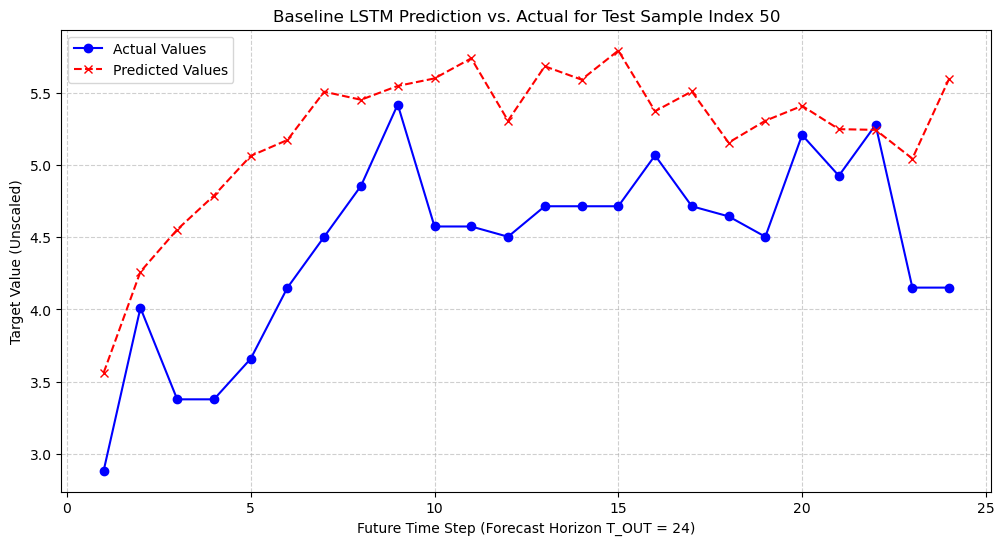

In [6]:
import matplotlib.pyplot as plt

# Choose a sample index to visualize (e.g., the 50th test sequence)
sample_index = 50 

# Extract the actual and predicted sequences for the chosen sample
# Squeeze the last dimension (which is 1) for plotting clarity
y_true_sample = Y_test_inv[sample_index].squeeze()
y_pred_sample = base_pred_inv[sample_index].squeeze()

# Create the time steps for the prediction horizon (T_OUT)
time_steps = np.arange(1, T_OUT + 1)

plt.figure(figsize=(12, 6))
plt.plot(time_steps, y_true_sample, marker='o', linestyle='-', color='blue', label='Actual Values')
plt.plot(time_steps, y_pred_sample, marker='x', linestyle='--', color='red', label='Predicted Values')

plt.title(f'Baseline LSTM Prediction vs. Actual for Test Sample Index {sample_index}')
plt.xlabel(f'Future Time Step (Forecast Horizon T_OUT = {T_OUT})')
plt.ylabel('Target Value (Unscaled)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#

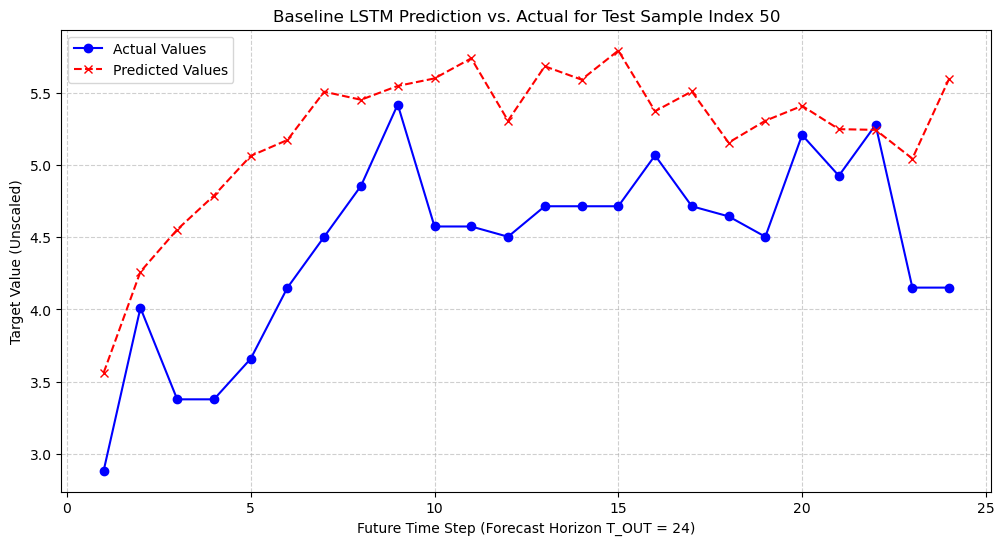

In [7]:
import matplotlib.pyplot as plt
import numpy as np
# Assuming Y_test_inv, base_pred_inv, and T_OUT are still defined in memory

# Choose a sample index to visualize (e.g., the 50th test sequence)
sample_index = 50 

# Extract the actual and predicted sequences for the chosen sample
# Squeeze the last dimension (which is 1) for plotting clarity
y_true_sample = Y_test_inv[sample_index].squeeze()
y_pred_sample = base_pred_inv[sample_index].squeeze()

# Create the time steps for the prediction horizon (T_OUT)
# Assuming T_OUT is the length of your prediction horizon (e.g., 5 or 10 steps)
time_steps = np.arange(1, T_OUT + 1)

plt.figure(figsize=(12, 6))
plt.plot(time_steps, y_true_sample, marker='o', linestyle='-', color='blue', label='Actual Values')
plt.plot(time_steps, y_pred_sample, marker='x', linestyle='--', color='red', label='Predicted Values')

plt.title(f'Baseline LSTM Prediction vs. Actual for Test Sample Index {sample_index}')
plt.xlabel(f'Future Time Step (Forecast Horizon T_OUT = {T_OUT})')
plt.ylabel('Target Value (Unscaled)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#